In [11]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("ad_spend.csv")
print(df.shape)
df.head()

(200, 3)


,Ad Spend ($),Season,Revenue ($)
0,463,Monsoon,440
1,158,Winter,297
2,328,Monsoon,214
3,322,Monsoon,48
4,726,Winter,1048


In [6]:
g = df.groupby("Season")[["Ad Spend ($)", "Revenue ($)"]].mean()
g

,Ad Spend ($),Revenue ($)
Season,,
Monsoon,517.643836,423.150685
Summer,573.836066,689.360656
Winter,552.560606,826.530303


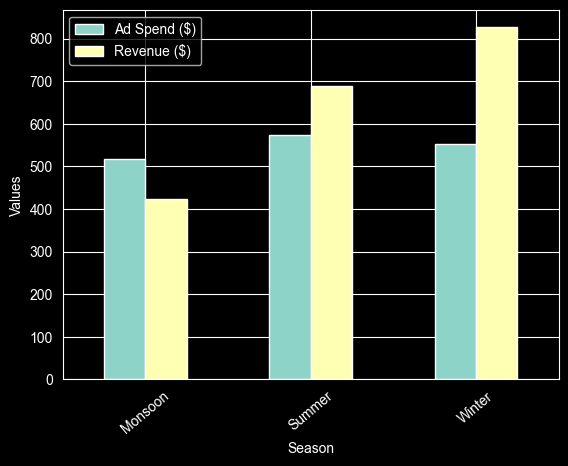

In [13]:
g.plot(kind="bar", rot=40)
plt.xlabel("Season")
plt.ylabel("Values")
plt.show()

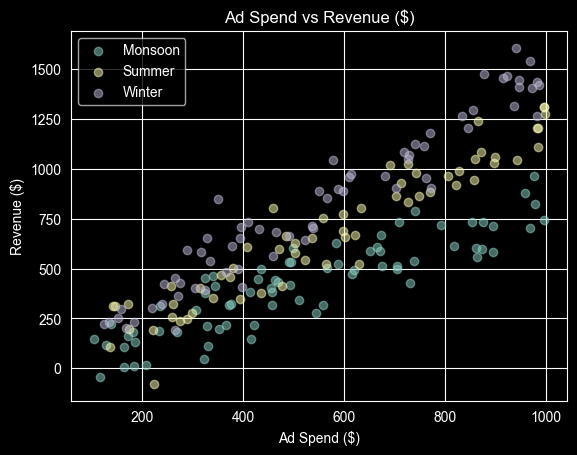

In [20]:
for season, subdf in df.groupby("Season"):
    plt.scatter(subdf["Ad Spend ($)"], subdf["Revenue ($)"], label=season,  alpha=0.5)

plt.xlabel("Ad Spend ($)")
plt.ylabel("Revenue ($)")
plt.title("Ad Spend vs Revenue ($)")
plt.legend()
plt.show()

## Hot encoding the season column and then train the model

In [22]:
df_encoded = pd.get_dummies(df, columns=["Season"], drop_first=True)
df_encoded.head()

,Ad Spend ($),Revenue ($),Season_Summer,Season_Winter
0,463,440,False,False
1,158,297,False,True
2,328,214,False,False
3,322,48,False,False
4,726,1048,False,True


In [23]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("Revenue ($)", axis=1)
y = df_encoded["Revenue ($)"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## Train linear Regression model

In [24]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
lr.score(X_test, y_test)

0.9004557896885321

## Train Decision tree regressor

In [25]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
dt.score(X_test, y_test)

0.8313762189435265

## Train Gradient Boosting Regressor

In [28]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)
gbr.score(X_test, y_test)

0.8785829427459309

In [32]:
df_evaluation = pd.DataFrame({"Actual": y_test , "Predicted": y_pred})
df_evaluation.head()

,Actual,Predicted
95,903,952.213112
15,1047,902.660844
30,1026,878.402352
158,1203,1288.656386
128,558,667.667675


In [41]:
df_evaluation["Diff %"] = abs((df_evaluation["Predicted"] -  df_evaluation["Actual"]) * 100 / df_evaluation["Actual"])

In [42]:
df_evaluation.head()

,Actual,Predicted,Diff %
95,903,952.213112,5.449957
15,1047,902.660844,13.785975
30,1026,878.402352,14.385736
158,1203,1288.656386,7.120232
128,558,667.667675,19.653705
